# Deep Q Networks

Code from : RLDMUU, UniNE 2026, jakub.tluczek@unine.ch

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
from collections import deque
import random

In [2]:
torch.manual_seed(123)
device = torch.device(torch.accelerator.current_accelerator() if torch.accelerator.is_available() else 'cpu')
np.random.seed(123)

In [3]:
# running mean function for the purpose of visualization
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

# CNN

Using CNN to train our DQN

In [4]:
class QNetwork(nn.Module):
  def __init__(self, input_shape, out_actions):
        super().__init__()

        # https://poloclub.github.io/cnn-explainer/
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=10, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.layer_stack = nn.Sequential(
            nn.Flatten(), # flatten inputs into a single vector
            # After flattening the matrix into a vector, pass it to the output layer. To determine the input shape, use the print() statement in forward()
            nn.Linear(in_features=10*4*1, out_features=out_actions)
        )
        
  def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        #print(x.shape)  # Use this to determine input shape of the output layer.
        x = self.layer_stack(x)
        return x

In [5]:
import torch 
import matplotlib.pyplot as plt

# ----------------- Generated by my friend Gemini ---------------------------

COLOR_PALETTE = torch.tensor([
    [0.1, 0.1, 0.1],  # 0: Empty
    [0.0, 0.8, 0.0],  # 1: Body
    [1.0, 0.0, 0.0],  # 2: Food
    [0.0, 0.0, 0.0],  # 3: Unused
    [0.0, 0.0, 0.0],  # 4: Unused
    [0.0, 0.4, 1.0],  # 5: Head facing UP
    [0.0, 1.0, 1.0],  # 6: Head facing RIGHT
    [1.0, 0.0, 1.0],  # 7: Head facing DOWN
    [1.0, 1.0, 0.0],  # 8: Head facing LEFT
], dtype=torch.float32).to(device)

def state_to_dqn_input(state)->torch.Tensor:
  tensor = torch.from_numpy(state).long()
  # Instant lookup! No loops.
  rgb_image = COLOR_PALETTE[tensor]  # Shape: (x, y, 3)
  cnn_input = rgb_image.permute(2, 0, 1).unsqueeze(0)
  # To see what the image looks like, uncomment out the following lines AND put a break point at the return statement.
  # pic = cnn_input.squeeze()      # input_tensor[batch][channel][row][column] - use squeeze to remove the batch level
  # pic = torch.movedim(pic, 0, 2)    # rearrange from [channel][row][column] to [row][column][channel]
  # plt.imshow(pic)                   # plot the image
  # plt.show()                        # show the image
  return cnn_input

def batch_state_to_dqn_input(states_tensor) -> torch.Tensor:
    """
    Expects states_tensor of shape: (Batch_Size, X, Y)
    Returns a colored tensor of shape: (Batch_Size, 3, X, Y)
    """
    # 1. Map colors to the entire batch simultaneously
    # Shape changes from (B, X, Y) -> (B, X, Y, 3)
    rgb_images = COLOR_PALETTE[states_tensor.long()]
    
    # 2. Permute channels from the back to the front for the CNN
    # We want to change (B, X, Y, 3) -> (B, 3, X, Y)
    # Dimension mapping: 0 stays 0 (Batch), 3 goes to 1 (Channels), 1 goes to 2 (X), 2 goes to 3 (Y)
    cnn_input = rgb_images.permute(0, 3, 1, 2)
    return cnn_input

In [6]:
class ReplayBuffer:
    def __init__(self, size):
        self.memory = deque([], maxlen=size)

    # this method samples transitions and returns tensors of each type registered in the environment step
    def sample(self, sample_size):
        sample = random.sample(self.memory, sample_size)
        states = []
        actions = []
        rewards = []
        next_states = []
        dones = []
        for x in sample:
            states.append(x[0])
            actions.append(x[1])
            rewards.append(x[2])
            next_states.append(x[3])
            dones.append(x[4])
        states_batched = torch.tensor(states, dtype=torch.float32).to(device)
        next_states_batched = torch.tensor(next_states, dtype=torch.float32).to(device)
        states = batch_state_to_dqn_input(states_batched).to(device)
        actions = torch.tensor(actions).to(device)
        rewards = torch.tensor(rewards).to(device)
        next_states = batch_state_to_dqn_input(next_states_batched).to(device)
        dones = torch.tensor(dones, dtype=torch.int).to(device)
        return states, actions, rewards, next_states, dones
    
    # add transition to the buffer
    def append(self, item):
        self.memory.append(item)

    def __len__(self):
        return len(self.memory)

In [7]:
policy_network = QNetwork(input_shape=3, out_actions=4).to(device)
policy_optimizer = torch.optim.Adam(params=policy_network.parameters(), lr=5e-4)
target_network = QNetwork(input_shape=3, out_actions=4).to(device)

In [8]:
def parameter_update(source_model, target_model, tau):
    for target_param, source_param in zip(target_model.parameters(), source_model.parameters()):
        target_param.data.copy_(tau * source_param.data + (1.0 - tau)*target_param.data)

In [9]:
from game_env.snake_env import SnakeEnv

env = SnakeEnv(obs="game", living_cost=True,width=8, height=8)
# state, _ = env.reset()
# print(state.shape)
# print(state)
# state_to_dqn_input(state)

/Users/borito/swissjm-cs/rldmuu/course/project/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [10]:
NUM_TRAJECTORIES = 2000
MAX_EPISODE_LENGTH = 500

gamma = 0.99
epsilon = 1
decay = epsilon / NUM_TRAJECTORIES
SOFT_UPDATE = 0.01
BATCH_SIZE = 512
# warmup steps to collect the data first
WARMUP = 1000

# placeholders for rewards for each episode
cumulative_rewards = []
policy_losses = []
# declaring the replay buffer
transition_buffer = ReplayBuffer(10000)
# iterating through trajectories
for tau in tqdm(range(NUM_TRAJECTORIES)):
  # resetting the environment
  state, info = env.reset()
  # setting done to False for while loop 
  done = False
  t = 0
  while done == False and t < MAX_EPISODE_LENGTH:
    # retrieving Q(s, a) for all possible a
    action_q_values = policy_network(state_to_dqn_input(state).to(device))
    # epsilon-greedy action
    action = np.random.choice(
          [torch.argmax(action_q_values.flatten()).detach().cpu().numpy(), 
            np.random.choice([0, 1, 2, 3])], 
            p=[1-epsilon, epsilon])
    # keeping track of previous state
    prev_state = state
    # environment step
    state, reward, done, truncation, info = env.step(action)

    transition_buffer.append((prev_state, action, reward, state, done))
      

    t += 1
  if len(transition_buffer) > WARMUP:
    states, actions, rewards, next_states, dones = transition_buffer.sample(sample_size=BATCH_SIZE)
    # getting the maximizing Q-value
    # max(x) return first x values ordered in a decreasing order
    q_target = target_network(next_states).detach().max(1)[0] # float for mps acceleration
    # using Q-values of target network only for non-terminal state
    expected_values = rewards + gamma * q_target*(torch.ones(BATCH_SIZE).to(device) - dones)
    # selecting Q-values of actions taken, using current policy network
    # gather() takes only values indicated by a given index, in this case, action taken
    output = policy_network(states).gather(1, actions.view(-1,1))
    # computing the loss between r + γ * max Q(s',a) and Q(s,a)
    loss = F.mse_loss(output.flatten(), expected_values)
    policy_losses.append(loss.item())
    policy_optimizer.zero_grad()
    loss.backward()
    policy_optimizer.step()
    # soft parameter update
    parameter_update(policy_network, target_network, SOFT_UPDATE)
    
  # logging the episode length as a cumulative reward
  cumulative_rewards.append(t)
  epsilon = max(epsilon - decay, 0)  

torch.save(policy_network.state_dict(), "snake_dql_cnn.pt")


  0%|          | 0/2000 [00:00<?, ?it/s]

  4%|▍         | 86/2000 [00:01<00:24, 76.78it/s]/var/folders/kv/b1gslbxj1sb_wvrlx344hk780000gn/T/ipykernel_12501/2455484873.py:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  states_batched = torch.tensor(states, dtype=torch.float32).to(device)
100%|██████████| 2000/2000 [02:52<00:00, 11.57it/s]


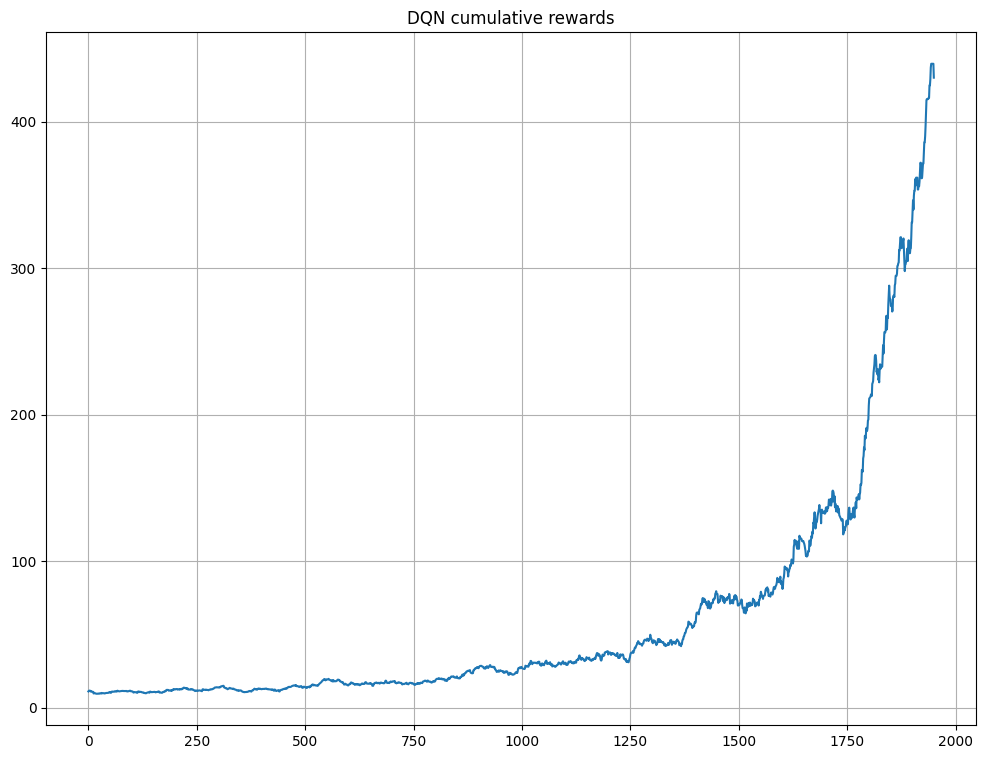

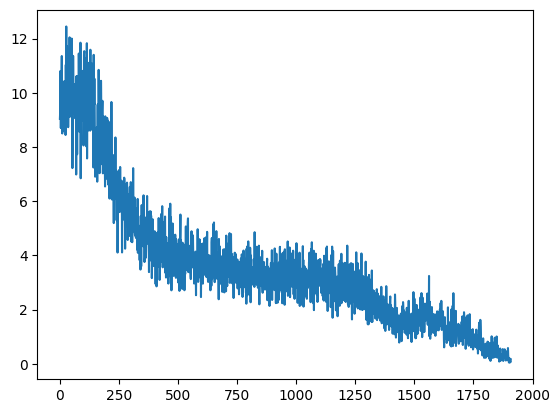

In [11]:
plt.figure(figsize=(12,9))
plt.plot(running_mean(cumulative_rewards, 50))
plt.title("DQN cumulative rewards")
plt.grid()
plt.figure()
plt.plot(policy_losses)